# Data Loading

In [ ]:
!pip install tensorflow_io

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 20.5 MB/s eta 0:00:00


In [ ]:
import os
import librosa
from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kagglehub
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_io as tfio
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import math
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.models import load_model

/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl8str_util8EndsWithESt17basic_string_viewIcSt11char_traitsIcEES4_']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZN3tsl8str_util9LowercaseB5cxx11ESt17basic_s

In [ ]:
# Download latest version
path = kagglehub.dataset_download("warcoder/infant-cry-audio-corpus")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/infant-cry-audio-corpus


In [ ]:
root_dir = '/kaggle/input/infant-cry-audio-corpus/donateacry_corpus'
subfolders = ['belly_pain', 'burping', 'discomfort', 'hungry','tired']

In [ ]:
file_paths = []
labels = []

def collect_files_and_labels(base_dir, subfolders, file_paths, labels):
    for folder_name in subfolders:
        folder_path = os.path.join(base_dir, folder_name)
        if os.path.isdir(folder_path):
            for file_name in os.listdir(folder_path):
                if file_name.endswith('.wav'):
                    file_path = os.path.join(folder_path, file_name)
                    file_paths.append(file_path)
                    labels.append(folder_name)

collect_files_and_labels(root_dir, subfolders, file_paths, labels)

In [ ]:
yamnet_model_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(yamnet_model_handle)

In [ ]:
df = pd.DataFrame({
    'File Path': file_paths,
    'Label': labels
})

In [ ]:
df

,File Path,Label
0,/kaggle/input/infant-cry-audio-corpus/donateac...,belly_pain
1,/kaggle/input/infant-cry-audio-corpus/donateac...,belly_pain
2,/kaggle/input/infant-cry-audio-corpus/donateac...,belly_pain
3,/kaggle/input/infant-cry-audio-corpus/donateac...,belly_pain
4,/kaggle/input/infant-cry-audio-corpus/donateac...,belly_pain
...,...,...
452,/kaggle/input/infant-cry-audio-corpus/donateac...,tired
453,/kaggle/input/infant-cry-audio-corpus/donateac...,tired
454,/kaggle/input/infant-cry-audio-corpus/donateac...,tired
455,/kaggle/input/infant-cry-audio-corpus/donateac...,tired


# Describe Data

In [ ]:
print("Jumlah setiap label:\n", df['Label'].value_counts())
print("Total data:", df['Label'].value_counts().sum())

Jumlah setiap label:
 Label
hungry        382
discomfort     27
tired          24
belly_pain     16
burping         8
Name: count, dtype: int64
Total data: 457


# Exploratory Data

/tmp/ipython-input-11-1413262157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', palette='hot')


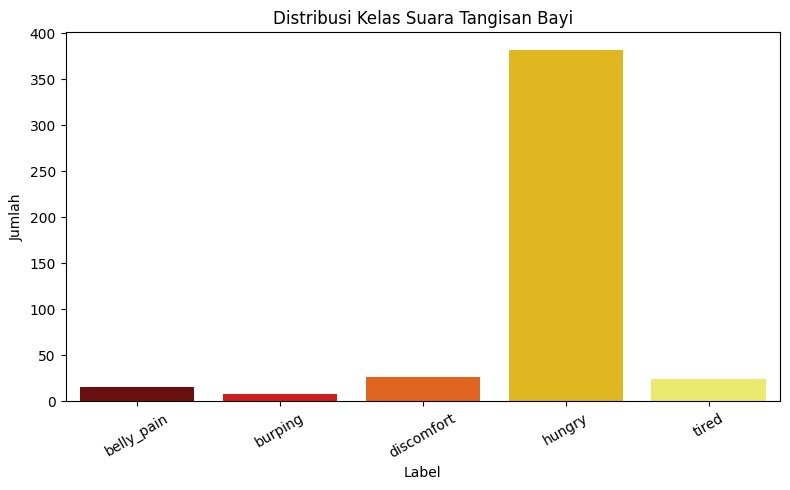

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Label', palette='hot')
plt.title('Distribusi Kelas Suara Tangisan Bayi')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


count    457.000000
mean       6.918293
std        0.113685
min        6.520000
25%        6.880000
50%        6.960000
75%        7.000000
max        7.060000
Name: Durasi, dtype: float64


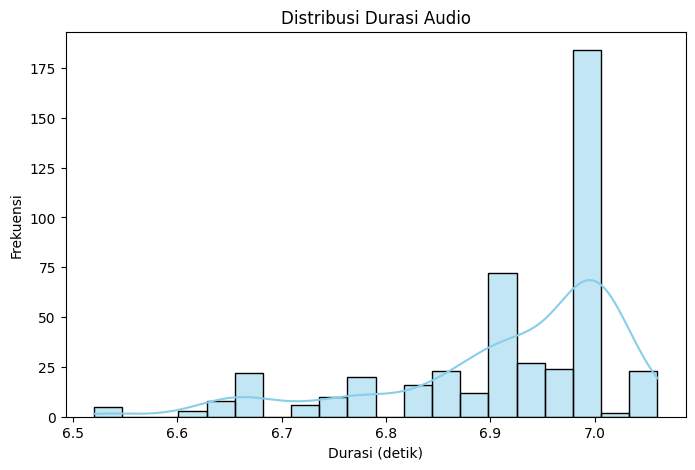

In [ ]:
# Tambahkan kolom durasi ke dataframe
durasi = []

for path in df['File Path']:
    y, sr = librosa.load(path, sr=16000)
    durasi.append(len(y) / sr)

df['Durasi'] = durasi

# Statistik durasi
print(df['Durasi'].describe())

# Visualisasi distribusi durasi
plt.figure(figsize=(8,5))
sns.histplot(df['Durasi'], bins=20, kde=True, color='skyblue')
plt.title("Distribusi Durasi Audio")
plt.xlabel("Durasi (detik)")
plt.ylabel("Frekuensi")
plt.show()


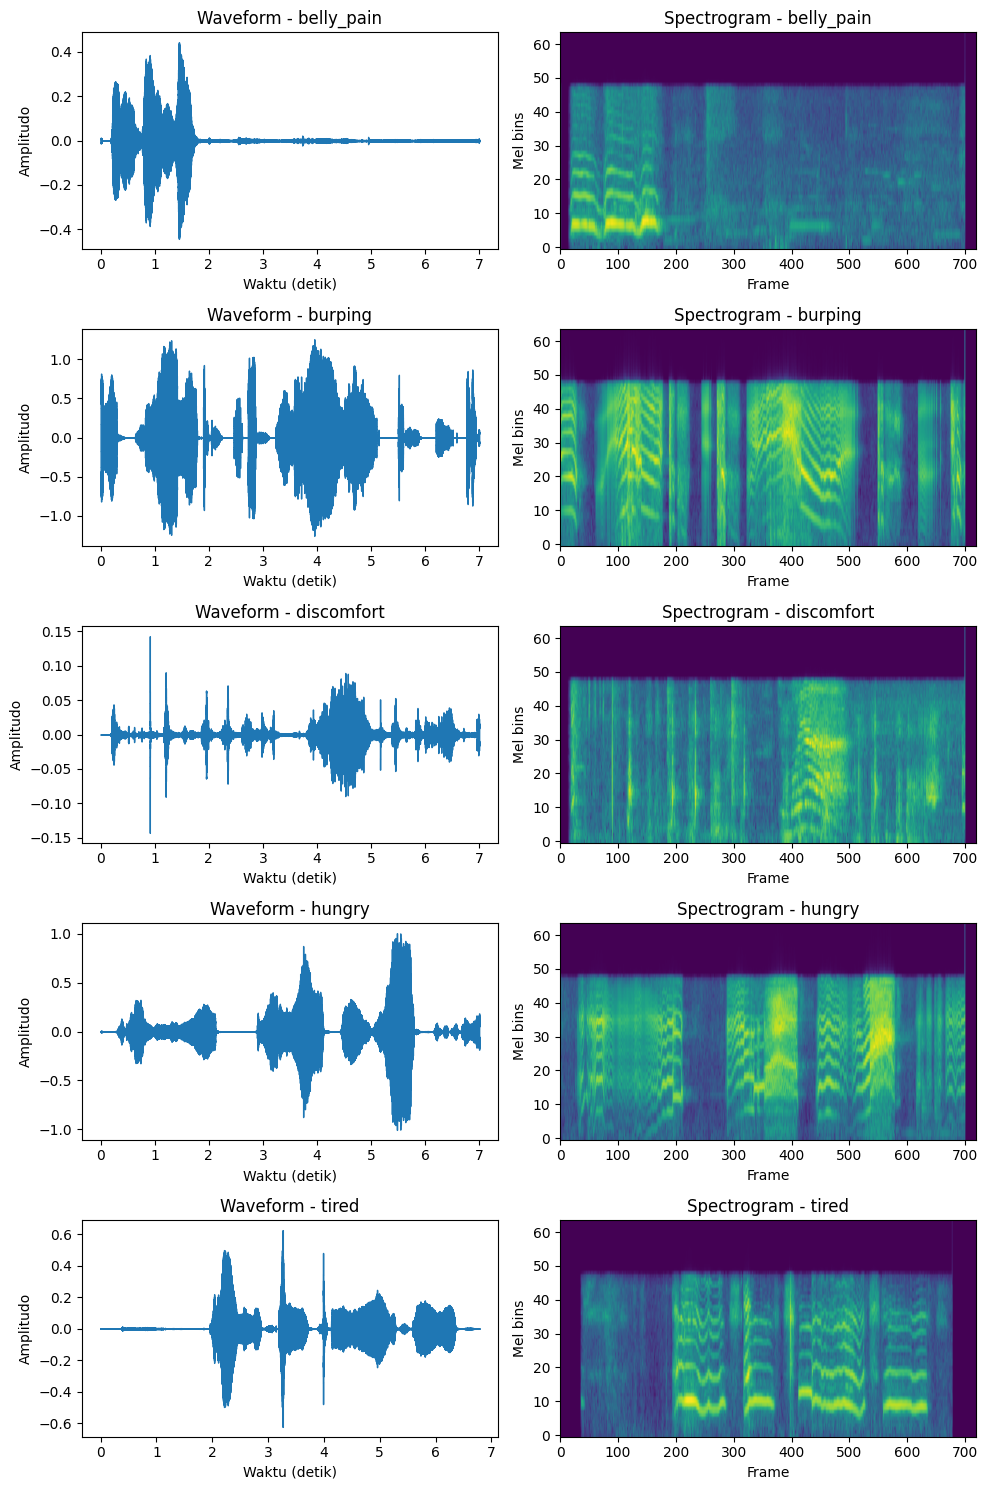

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display

# Ambil daftar kelas unik
unique_labels = df['Label'].unique()

# Atur ukuran figure berdasarkan jumlah kelas
num_classes = len(unique_labels)
plt.figure(figsize=(10, num_classes * 3))

for i, label in enumerate(unique_labels):
    # Ambil satu file audio dari masing-masing kelas
    sample_path = df[df['Label'] == label]['File Path'].iloc[0]
    waveform, sr = librosa.load(sample_path, sr=16000)

    # Inference pakai YAMNet
    scores, embeddings, spectrogram = yamnet_model(waveform)
    spectrogram_np = spectrogram.numpy()

    # Plot waveform
    plt.subplot(num_classes, 2, 2*i+1)
    librosa.display.waveshow(waveform, sr=sr)
    plt.title(f"Waveform - {label}")
    plt.xlabel("Waktu (detik)")
    plt.ylabel("Amplitudo")

    # Plot spectrogram
    plt.subplot(num_classes, 2, 2*i+2)
    plt.imshow(spectrogram_np.T, aspect='auto', origin='lower')
    plt.title(f"Spectrogram - {label}")
    plt.ylabel("Mel bins")
    plt.xlabel("Frame")

plt.tight_layout()
plt.show()


In [ ]:
# Ekstrak karakter 'm' atau 'f' di antara tanda strip
df['Gender'] = df['File Path'].str.extract(r'-(m|f)-')

# Konversi singkatan ke label lengkap
df['Gender'] = df['Gender'].map({'m': 'Male', 'f': 'Female'})

print("Distribusi Gender:")
print(df['Gender'].value_counts())


Distribusi Gender:
Gender
Male      276
Female    181
Name: count, dtype: int64


/tmp/ipython-input-14-2421416690.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='hot')


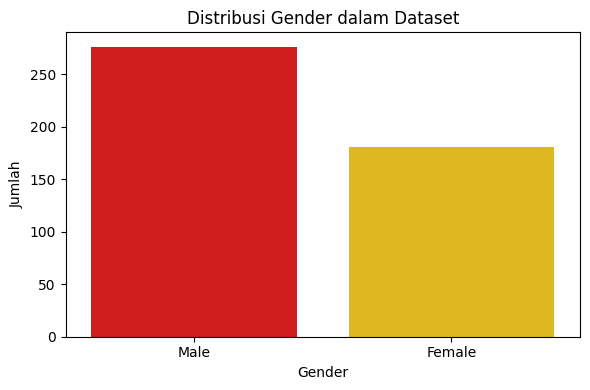

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', palette='hot')
plt.title('Distribusi Gender dalam Dataset')
plt.xlabel('Gender')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()


In [ ]:
df

,File Path,Label,Durasi,Gender
0,/kaggle/input/infant-cry-audio-corpus/donateac...,belly_pain,7.00,Male
1,/kaggle/input/infant-cry-audio-corpus/donateac...,belly_pain,7.00,Male
2,/kaggle/input/infant-cry-audio-corpus/donateac...,belly_pain,7.00,Male
3,/kaggle/input/infant-cry-audio-corpus/donateac...,belly_pain,7.00,Male
4,/kaggle/input/infant-cry-audio-corpus/donateac...,belly_pain,6.90,Male
...,...,...,...,...
452,/kaggle/input/infant-cry-audio-corpus/donateac...,tired,6.68,Female
453,/kaggle/input/infant-cry-audio-corpus/donateac...,tired,6.92,Female
454,/kaggle/input/infant-cry-audio-corpus/donateac...,tired,6.52,Female
455,/kaggle/input/infant-cry-audio-corpus/donateac...,tired,6.88,Female


# Preprocessing Data

In [ ]:
df_hungry     = df[df['Label'] == 'hungry']
df_discomfort = df[df['Label'] == 'discomfort']
df_tired      = df[df['Label'] == 'tired']
df_belly      = df[df['Label'] == 'belly_pain']
df_burp       = df[df['Label'] == 'burping']


In [ ]:
# Tentukan jumlah target sample untuk semua kelas
target_count = 300

# Oversample kelas minor (replace=True artinya boleh duplikat)
df_discomfort_upsampled = resample(df_discomfort, replace=True, n_samples=target_count, random_state=42)
df_tired_upsampled      = resample(df_tired, replace=True, n_samples=target_count, random_state=42)
df_belly_upsampled      = resample(df_belly, replace=True, n_samples=target_count, random_state=42)
df_burp_upsampled       = resample(df_burp, replace=True, n_samples=target_count, random_state=42)
df_hungry_downsampled   = resample(df_hungry, replace=False, n_samples=target_count, random_state=42)  # Optional: samakan jumlah

In [ ]:
# Gabungkan semua
df_balanced = pd.concat([
    df_hungry_downsampled,
    df_discomfort_upsampled,
    df_tired_upsampled,
    df_belly_upsampled,
    df_burp_upsampled
])

# Acak ulang
df = df_balanced.sample(frac=1).reset_index(drop=True)

# Cek hasil akhir
print("Setelah oversampling:\n", df['Label'].value_counts())

Setelah oversampling:
 Label
belly_pain    300
hungry        300
discomfort    300
burping       300
tired         300
Name: count, dtype: int64


/tmp/ipython-input-19-3131309295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', palette='hot')


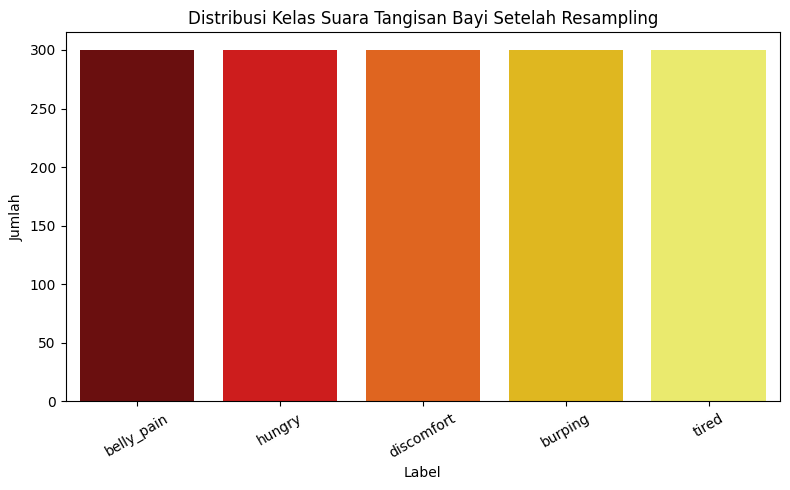

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Label', palette='hot')
plt.title('Distribusi Kelas Suara Tangisan Bayi Setelah Resampling')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
df.to_csv('infant_cry.csv', index=False)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Label'] = label_encoder.fit_transform(df['Label'])
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

In [ ]:
df

,File Path,Label,Durasi,Gender
0,/kaggle/input/infant-cry-audio-corpus/donateac...,0,7.00,Male
1,/kaggle/input/infant-cry-audio-corpus/donateac...,0,7.00,Male
2,/kaggle/input/infant-cry-audio-corpus/donateac...,3,7.00,Female
3,/kaggle/input/infant-cry-audio-corpus/donateac...,0,7.00,Female
4,/kaggle/input/infant-cry-audio-corpus/donateac...,3,7.00,Male
...,...,...,...,...
1495,/kaggle/input/infant-cry-audio-corpus/donateac...,1,7.00,Female
1496,/kaggle/input/infant-cry-audio-corpus/donateac...,3,7.00,Female
1497,/kaggle/input/infant-cry-audio-corpus/donateac...,3,6.84,Male
1498,/kaggle/input/infant-cry-audio-corpus/donateac...,1,7.00,Female


In [ ]:
df_train, df_temp = train_test_split(
    df,
    stratify=df['Label'],
    test_size=0.2,
    random_state=42
)

df_validation, df_test = train_test_split(
    df_temp,
    stratify=df_temp['Label'],
    test_size=0.5,
    random_state=42
)

print(len(df_train), len(df_validation), len(df_test))

1200 150 150


# Modelling

In [ ]:
def load_wav_16k_mono(filename):
    y, sr = librosa.load(filename.numpy().decode(), sr=16000, mono=True)
    return tf.convert_to_tensor(y, dtype=tf.float32)


In [ ]:
def wav_map(file_path, label):
    audio = tf.py_function(load_wav_16k_mono, inp=[file_path], Tout=tf.float32)
    audio.set_shape([None])
    return audio, label


def extract_mean_embedding(wav_data, label):
    _, embeddings, _ = yamnet_model(wav_data)
    mean_embedding = tf.reduce_mean(embeddings, axis=0)
    return mean_embedding, label

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((df_train['File Path'], df_train['Label']))
valid_ds = tf.data.Dataset.from_tensor_slices((df_validation['File Path'], df_validation['Label']))
test_ds = tf.data.Dataset.from_tensor_slices((df_test['File Path'], df_test['Label']))

train_ds = train_ds.map(wav_map)
valid_ds = valid_ds.map(wav_map)
test_ds = test_ds.map(wav_map)

train_ds = train_ds.map(extract_mean_embedding)
valid_ds = valid_ds.map(extract_mean_embedding)
test_ds = test_ds.map(extract_mean_embedding)


train_ds = train_ds.cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
valid_ds = valid_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)

train_ds = train_ds.repeat()
train_ds.element_spec

(TensorSpec(shape=(None, 1024), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int64, name=None))

In [ ]:
tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024,)),
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation='softmax')
])

In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=100,
    steps_per_epoch=math.ceil(len(df_train) / 32),
    validation_steps=math.ceil(len(df_validation) / 32),
    callbacks=[early_stopping]
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 90s 518ms/step - accuracy: 0.3939 - loss: 2.9578 - val_accuracy: 0.3733 - val_loss: 2.6483
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7212 - loss: 1.8685 - val_accuracy: 0.4133 - val_loss: 2.4020
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8004 - loss: 1.6009 - val_accuracy: 0.4600 - val_loss: 2.1960
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8318 - loss: 1.4884 - val_accuracy: 0.5200 - val_loss: 1.9689
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9001 - loss: 1.2735 - val_accuracy: 0.6267 - val_loss: 1.7474
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8812 - loss: 1.2282 - val_accuracy: 0.7133 - val_loss: 1.5064
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9188 - loss: 1.1274 - val_accuracy: 0.6733 - val_loss: 1.4415
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9138 - loss: 1.1311 - val_accuracy: 0.7933 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step


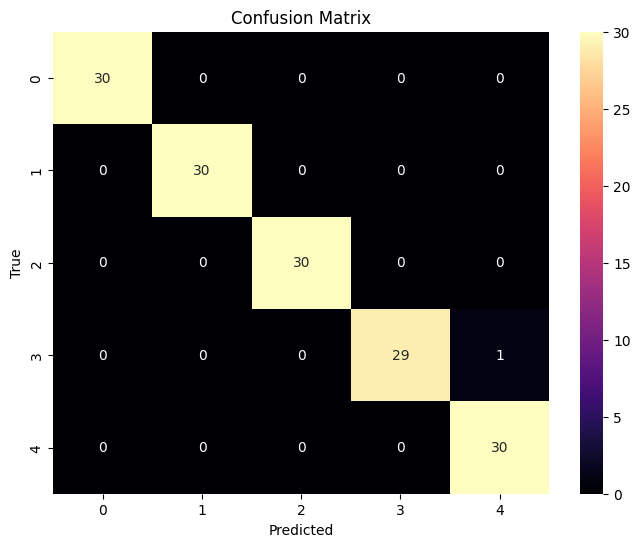

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        30
           3       1.00      0.97      0.98        30
           4       0.97      1.00      0.98        30

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



In [ ]:
# Prediksi
y_true = []
y_pred = []
for x, y in test_ds:
    pred = model.predict(x)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(pred, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_true, y_pred))


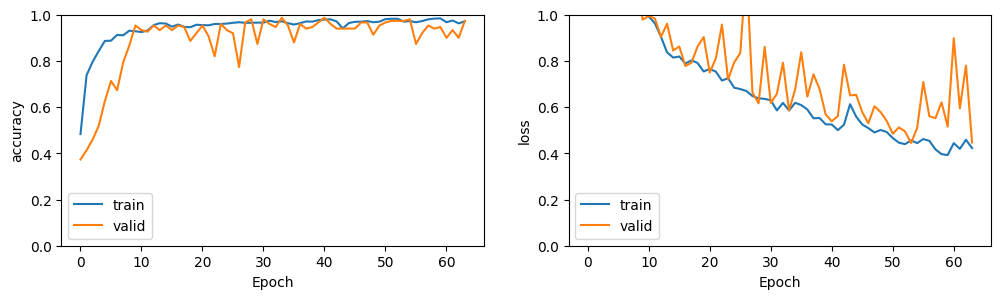

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
ax = axes.ravel()

for i, metric in enumerate(['accuracy', 'loss']):
    ax[i].plot(history.history[metric])
    ax[i].plot(history.history['val_' + metric])
    ax[i].set_xlabel('Epoch')
    ax[i].set_ylabel(metric)
    ax[i].set_ylim([0, 1])
    ax[i].legend(['train', 'valid'])

plt.show()

In [ ]:
predicted_labels = []

for path in df_test['File Path']:
    # Load audio
    waveform, sr = librosa.load(path, sr=16000)
    waveform = tf.convert_to_tensor(waveform, dtype=tf.float32)

    # Ekstrak embedding dari YAMNet
    _, embeddings, _ = yamnet_model(waveform)
    mean_embedding = tf.reduce_mean(embeddings, axis=0)
    mean_embedding = tf.expand_dims(mean_embedding, axis=0)

    # Prediksi dengan model
    prediction = model.predict(mean_embedding)
    pred_index = np.argmax(prediction)
    predicted_labels.append(pred_index)

# Tambahkan hasil prediksi ke df_test
df_test = df_test.copy()
df_test['Predicted'] = predicted_labels
df_test['Predicted_Label'] = label_encoder.inverse_transform(df_test['Predicted'])
df_test['True_Label'] = label_encoder.inverse_transform(df_test['Label'])

# Lihat hasil
df_test[['File Path', 'True_Label', 'Predicted_Label']].head()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━

,File Path,True_Label,Predicted_Label
15,/kaggle/input/infant-cry-audio-corpus/donateac...,hungry,hungry
397,/kaggle/input/infant-cry-audio-corpus/donateac...,tired,tired
1443,/kaggle/input/infant-cry-audio-corpus/donateac...,burping,burping
79,/kaggle/input/infant-cry-audio-corpus/donateac...,discomfort,discomfort
11,/kaggle/input/infant-cry-audio-corpus/donateac...,hungry,hungry


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(df_test['Label'], df_test['Predicted'])
print("Akurasi pada df_test: {:.2f}%".format(accuracy * 100))
print("\nClassification Report:\n")
print(classification_report(df_test['Label'], df_test['Predicted'], target_names=label_encoder.classes_))


Akurasi pada df_test: 99.33%

Classification Report:

              precision    recall  f1-score   support

  belly_pain       1.00      1.00      1.00        30
     burping       1.00      1.00      1.00        30
  discomfort       1.00      1.00      1.00        30
      hungry       1.00      0.97      0.98        30
       tired       0.97      1.00      0.98        30

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



In [ ]:
df_test

,File Path,Label,Durasi,Gender,Predicted,Predicted_Label,True_Label
31,/kaggle/input/infant-cry-audio-corpus/donateac...,3,7.02,Female,3,hungry,hungry
410,/kaggle/input/infant-cry-audio-corpus/donateac...,4,6.68,Female,4,tired,tired
1445,/kaggle/input/infant-cry-audio-corpus/donateac...,1,6.54,Male,1,burping,burping
91,/kaggle/input/infant-cry-audio-corpus/donateac...,2,7.00,Male,2,discomfort,discomfort
27,/kaggle/input/infant-cry-audio-corpus/donateac...,3,7.00,Female,3,hungry,hungry
...,...,...,...,...,...,...,...
1085,/kaggle/input/infant-cry-audio-corpus/donateac...,3,6.92,Male,3,hungry,hungry
230,/kaggle/input/infant-cry-audio-corpus/donateac...,0,7.00,Male,0,belly_pain,belly_pain
1159,/kaggle/input/infant-cry-audio-corpus/donateac...,2,6.66,Male,2,discomfort,discomfort
176,/kaggle/input/infant-cry-audio-corpus/donateac...,0,7.00,Male,0,belly_pain,belly_pain


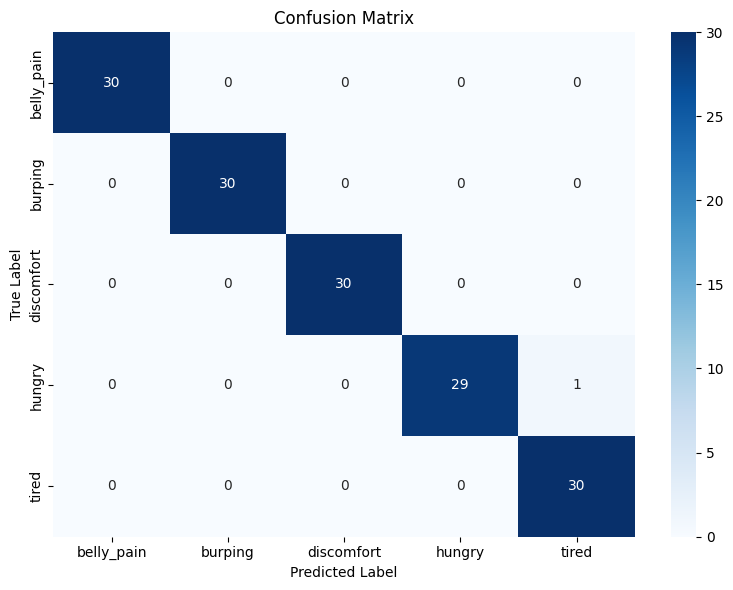

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Konversi y_true dan y_pred menjadi angka menggunakan LabelEncoder
y_true_enc = label_encoder.transform(df_test['True_Label'])
y_pred_enc = label_encoder.transform(df_test['Predicted_Label'])

# Buat confusion matrix-nya
cm = confusion_matrix(y_true_enc, y_pred_enc)

# Ambil nama-nama label asli untuk ditampilkan
labels_display = label_encoder.classes_

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_display,
            yticklabels=labels_display)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


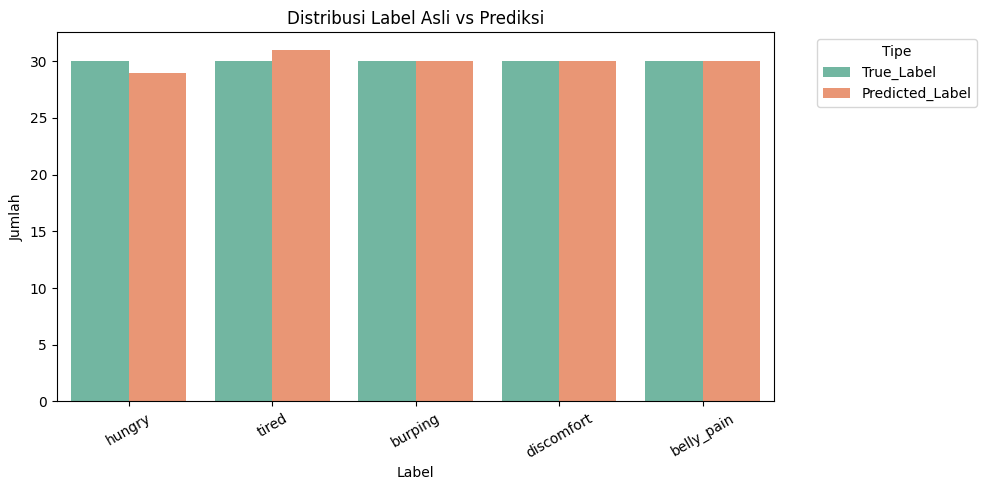

In [ ]:
# Buat DataFrame baru hanya berisi label asli dan hasil prediksi
df_vis = pd.DataFrame({
    'True_Label': label_encoder.inverse_transform(y_true),
    'Predicted_Label': label_encoder.inverse_transform(y_pred)
})

# Ubah dari wide ke long format untuk visualisasi
df_melted = pd.melt(df_vis, var_name='Tipe', value_name='Label')

# Visualisasi distribusi label
plt.figure(figsize=(10, 5))
sns.countplot(data=df_melted, x='Label', hue='Tipe', palette='Set2')
plt.title("Distribusi Label Asli vs Prediksi")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.xticks(rotation=30)
plt.legend(title='Tipe', bbox_to_anchor=(1.05, 1), loc='upper left')  # Geser legend ke kanan luar
plt.tight_layout()
plt.show()



In [ ]:
results = model.evaluate(test_ds, verbose=0)
print(f'Test Loss: {results[0]}')
print(f'Test Accuracy: {results[1]}')

Test Loss: 0.40203747153282166
Test Accuracy: 0.9933333396911621


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("best_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Model berhasil dikonversi ke best_model.tflite")

Saved artifact at '/tmp/tmpyv1kw2mu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137569391744144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137569391748560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137568887766864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137568887752656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137569391749904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137568882641040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137568887762448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137568887761680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137568887763792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137568887760336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137568887763600: Tens

In [ ]:
import tensorflow as tf

# Coba load model TFLite
try:
    interpreter = tf.lite.Interpreter(model_path="best_model.tflite")
    interpreter.allocate_tensors()
    print("✅ Model TFLite berhasil dimuat!")
except Exception as e:
    print("❌ Gagal memuat model TFLite:", e)

✅ Model TFLite berhasil dimuat!


In [ ]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("📥 Input shape:", input_details[0]['shape'])
print("📤 Output shape:", output_details[0]['shape'])

📥 Input shape: [   1 1024]
📤 Output shape: [1 5]


In [ ]:
import numpy as np

dummy_input = np.random.rand(*input_details[0]['shape']).astype(np.float32)

interpreter.set_tensor(input_details[0]['index'], dummy_input)
interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]['index'])
print("🧠 Output prediksi (dummy):", output_data)

🧠 Output prediksi (dummy): [[5.8919892e-07 3.0446122e-07 2.4550754e-04 9.9975258e-01 9.1769829e-07]]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
!pip install pipreqs
pipreqs "/content/drive/MyDrive/Colab Notebooks/Projek PI"


In [ ]:
# Save the trained model
model.save('best_model.h5')